In [73]:
import h5py
import numpy as np
from astropy.table import Table, vstack
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
import numpy as np
import math
import warnings
import matplotlib.pyplot as plt
import glob
import tables
from ctapipe.io import EventSource
from ctapipe.visualization import CameraDisplay

source = EventSource('/Users/vdk/muons2024/simtel_files/2024year_tuned_nooulier_reflectivity_additional/run101_muon.simtel.gz')

camgeom = source.subarray.tel[1].camera.geometry


In [2]:
def check_h5_structure(file_path):
    with h5py.File(file_path, "r") as h5_file:
        
        # List all groups in the file
        print("Groups in the file:")
        for group in h5_file:
            print(group)
        
        # You can also recursively list all datasets
        def print_structure(name, obj):
            print(f"{name}: {obj}")
        
        print("\nFile structure:")
        h5_file.visititems(print_structure)

In [3]:
check_h5_structure(dl1_filename)

NameError: name 'dl1_filename' is not defined

In [12]:
dl1_filename = '/Users/vdk/muons2025/lst-data/16903/output/run16903_0010_dl1.h5'

with tables.open_file(dl1_filename, "r") as h5_file:
    dataset = h5_file.get_node("/dl1/event/telescope/muon/tel_001")
    muon_dataset_dtype = dataset.dtype
    muon_data = dataset[:]
    dataset = h5_file.get_node("/dl1/event/telescope/images/tel_001")
    image_dataset_dtype = dataset.dtype
    image_data = dataset[:]
    
    # Query muon data (example: filtering rows where some_field > threshold)
    #filtered_muon_data = [row for row in muon_dataset.where("some_field > 10.0")]

muon_table = Table(np.array(muon_data, dtype=muon_dataset_dtype))
image_table = Table(np.array(image_data, dtype=image_dataset_dtype))

In [13]:
muon_table


obs_id,event_id,tel_id,muonring_center_fov_lon,muonring_center_fov_lat,muonring_radius,muonring_center_phi,muonring_center_distance,muonparameters_containment,muonparameters_completeness,muonparameters_intensity_ratio,muonparameters_mean_squared_error,muonparameters_ring_intensity,muonparameters_intensity_outside_ring,muonparameters_n_pixels_in_ring,muonparameters_mean_intensity_outside_ring,muonparameters_standard_dev,muonparameters_skewness,muonparameters_excess_kurtosis,muonefficiency_width,muonefficiency_impact,muonefficiency_impact_x,muonefficiency_impact_y,muonefficiency_optical_efficiency,muonefficiency_is_valid,muonefficiency_parameters_at_limit,muonefficiency_likelihood_value
int64,int64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,float64
16903,598081,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598082,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598083,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598084,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598085,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598086,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598087,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598088,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan
16903,598089,1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,-1,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,False,nan


In [61]:
for col_name in muon_table.columns:
    print(col_name)

obs_id
event_id
tel_id
muonring_center_fov_lon
muonring_center_fov_lat
muonring_radius
muonring_center_phi
muonring_center_distance
muonparameters_containment
muonparameters_completeness
muonparameters_intensity_ratio
muonparameters_mean_squared_error
muonparameters_ring_intensity
muonparameters_intensity_outside_ring
muonparameters_n_pixels_in_ring
muonparameters_mean_intensity_outside_ring
muonparameters_standard_dev
muonparameters_skewness
muonparameters_excess_kurtosis
muonefficiency_width
muonefficiency_impact
muonefficiency_impact_x
muonefficiency_impact_y
muonefficiency_optical_efficiency
muonefficiency_is_valid
muonefficiency_parameters_at_limit
muonefficiency_likelihood_value


In [46]:
intensity_mask = ~np.isnan(muon_table['muonparameters_ring_intensity'])
muon_table[intensity_mask]

obs_id,event_id,tel_id,muonring_center_fov_lon,muonring_center_fov_lat,muonring_radius,muonring_center_phi,muonring_center_distance,muonparameters_containment,muonparameters_completeness,muonparameters_intensity_ratio,muonparameters_mean_squared_error,muonparameters_ring_intensity,muonparameters_intensity_outside_ring,muonparameters_n_pixels_in_ring,muonparameters_mean_intensity_outside_ring,muonparameters_standard_dev,muonparameters_skewness,muonparameters_excess_kurtosis,muonefficiency_width,muonefficiency_impact,muonefficiency_impact_x,muonefficiency_impact_y,muonefficiency_optical_efficiency,muonefficiency_is_valid,muonefficiency_parameters_at_limit,muonefficiency_likelihood_value
int64,int64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,float64
16903,598139,1,-0.001332756465668045,0.0026883048947722566,1.713248063593574,116.37041605971606,0.0030005371192565597,1.0,1.0,0.09546409547328949,0.33671725680099934,67290.5,47342.7421875,1104,63.13838577270508,0.5256050700444601,-0.5176757954518814,-0.6321050190050963,nan,nan,nan,nan,nan,False,False,nan
16903,598207,1,-0.006723762879594679,0.00513162541140469,1.7084791412053422,142.64885945311474,0.00845828390537878,1.0,1.0,0.0949602723121643,0.334474011131161,67875.046875,46894.58203125,1108,62.74592208862305,0.5245457040981363,-0.5201225777211261,-0.6189640370628293,nan,nan,nan,nan,nan,False,False,nan
16903,598267,1,7.468639362709085e-05,0.0006862730411537422,1.716423302245399,83.78900240423212,0.0006903251005196225,1.0,1.0,0.09787328541278839,0.3354282856836856,72132.296875,48422.62890625,1116,65.78502655029297,0.5250797009455356,-0.5334695089182829,-0.6130645807882811,nan,nan,nan,nan,nan,False,False,nan
16903,598337,1,-0.0020964293901091354,0.0014431298145035154,1.7147997803114987,145.45744347898662,0.0025451207926584373,1.0,1.0,0.0977109745144844,0.3352721767054184,69356.125,47504.4453125,1107,63.455657958984375,0.5248970427379683,-0.5301243822346867,-0.6139847976756201,nan,nan,nan,nan,nan,False,False,nan
16903,598420,1,-0.004876284672776022,0.003872635215515769,1.7114612446780002,141.54419032965504,0.006226994116136871,1.0,1.0,0.09659022092819214,0.33453392169906826,70799.4375,48423.671875,1107,64.74203491210938,0.5244289969660231,-0.5310247662715407,-0.6079644543414604,nan,nan,nan,nan,nan,False,False,nan
16903,598428,1,0.7376441407281427,0.42997728632909454,0.45328444827154724,30.238170881224807,0.8538145847369275,1.0,1.0,0.2379552125930786,0.07863890558923575,20930.484375,43418.34375,77,254.65061950683594,0.3600395609187464,2.4344258443518814,8.262769491616101,nan,nan,nan,nan,nan,False,False,nan
16903,598504,1,-0.004644479739536335,0.0026023526011938625,1.7161268012212618,150.73761502362902,0.005323854910861486,1.0,1.0,0.09907295554876328,0.33642986933248437,71942.015625,48550.0546875,1109,64.9635238647461,0.5258524084791331,-0.5389591686894013,-0.6064235451571816,nan,nan,nan,nan,nan,False,False,nan
16903,598634,1,-0.29524926484662656,-1.4494131568384998,0.7171749205462516,-101.51377184512471,1.479179038388869,0.884513634974993,1.0,0.29873308539390564,0.05889617118110739,5400.359375,3532.847412109375,98,16.167848587036133,0.4055468591028371,2.398922021563805,10.443944059481646,nan,nan,nan,nan,nan,False,False,nan
16903,598635,1,-0.0033403787035629936,0.0004100969995642774,1.7137042557899083,173.00084375249392,0.0033654582796803184,1.0,1.0,0.09697184711694717,0.3282895028241138,71571.5625,48771.953125,1106,65.75867462158203,0.5204426760766838,-0.5283193376740574,-0.6043349150647375,nan,nan,nan,nan,nan,False,False,nan


In [45]:
intensity_mask = ~np.isnan(muon_table['muonefficiency_optical_efficiency'])
muon_table[intensity_mask]

obs_id,event_id,tel_id,muonring_center_fov_lon,muonring_center_fov_lat,muonring_radius,muonring_center_phi,muonring_center_distance,muonparameters_containment,muonparameters_completeness,muonparameters_intensity_ratio,muonparameters_mean_squared_error,muonparameters_ring_intensity,muonparameters_intensity_outside_ring,muonparameters_n_pixels_in_ring,muonparameters_mean_intensity_outside_ring,muonparameters_standard_dev,muonparameters_skewness,muonparameters_excess_kurtosis,muonefficiency_width,muonefficiency_impact,muonefficiency_impact_x,muonefficiency_impact_y,muonefficiency_optical_efficiency,muonefficiency_is_valid,muonefficiency_parameters_at_limit,muonefficiency_likelihood_value
int64,int64,int16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,float64


Text(0, 0.5, 'Normalized Frequency')

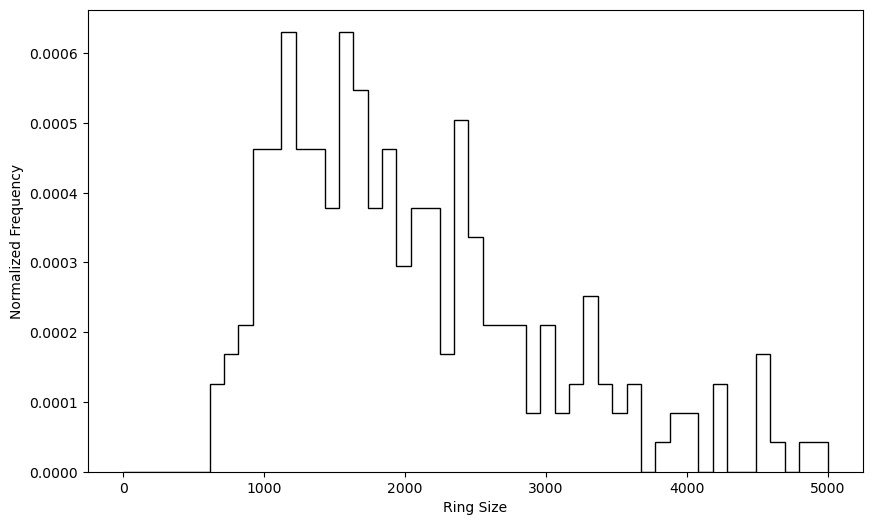

In [51]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[muon_table['muonparameters_ring_intensity'] < 20000]['muonparameters_ring_intensity'], 
    bins = np.linspace(0,5000,50), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Ring Size')
plt.ylabel('Normalized Frequency')

Text(0, 0.5, 'Normalized Frequency')

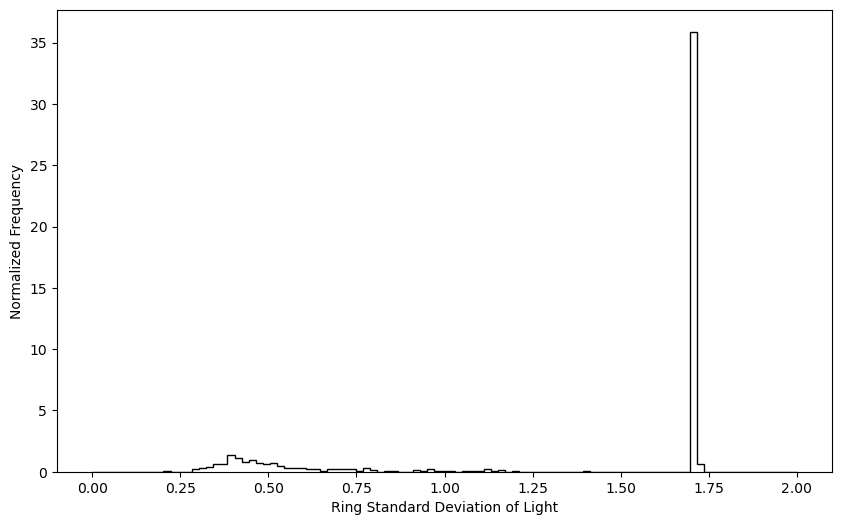

In [54]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[muon_table['muonparameters_ring_intensity'] > 0]['muonring_radius'], 
    bins = np.linspace(0,2,100), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Ring Standard Deviation of Light')
plt.ylabel('Normalized Frequency')

Text(0, 0.5, 'Normalized Frequency')

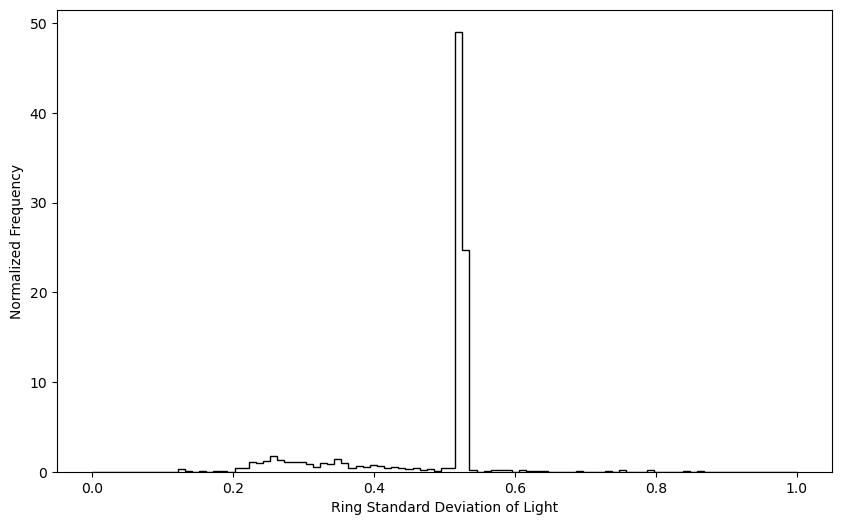

In [37]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[muon_table['muonparameters_ring_intensity'] > 0]['muonparameters_standard_dev'], 
    bins = np.linspace(0,1,100), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Ring Standard Deviation of Light')
plt.ylabel('Normalized Frequency')

Text(0, 0.5, 'Normalized Frequency')

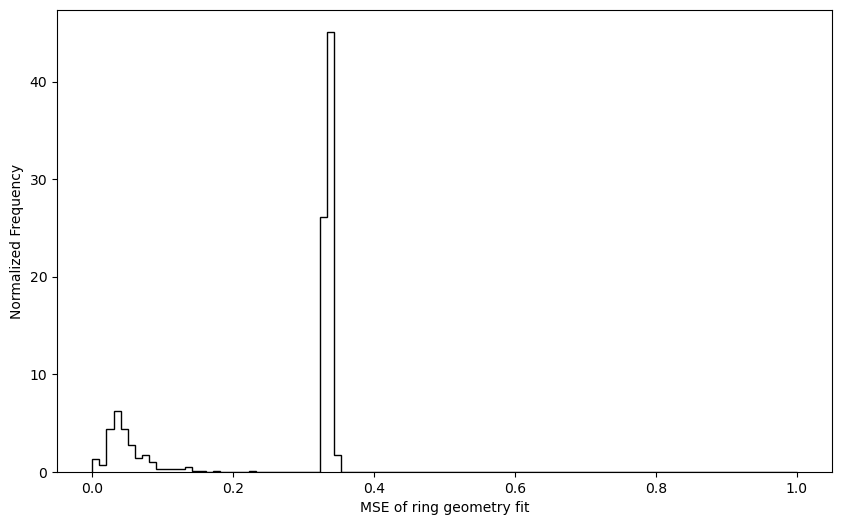

In [39]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[muon_table['muonparameters_ring_intensity'] > 0]['muonparameters_mean_squared_error'], 
    bins = np.linspace(0,1,100), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('MSE of ring geometry fit')
plt.ylabel('Normalized Frequency')

# Applying cuts

Text(0, 0.5, 'Normalized Frequency')

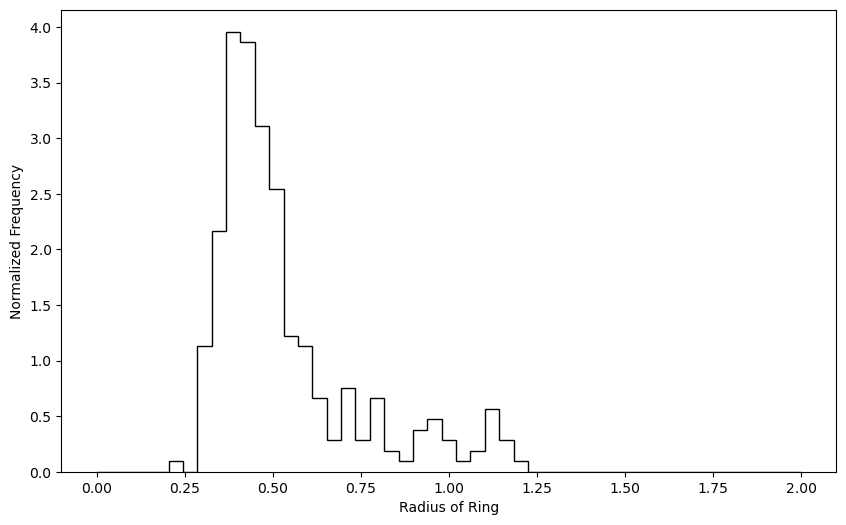

In [57]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[muon_table['muonparameters_ring_intensity'] < 10000]['muonring_radius'], 
    bins = np.linspace(0,2,50), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Radius of Ring')
plt.ylabel('Normalized Frequency')

Text(0, 0.5, 'Normalized Frequency')

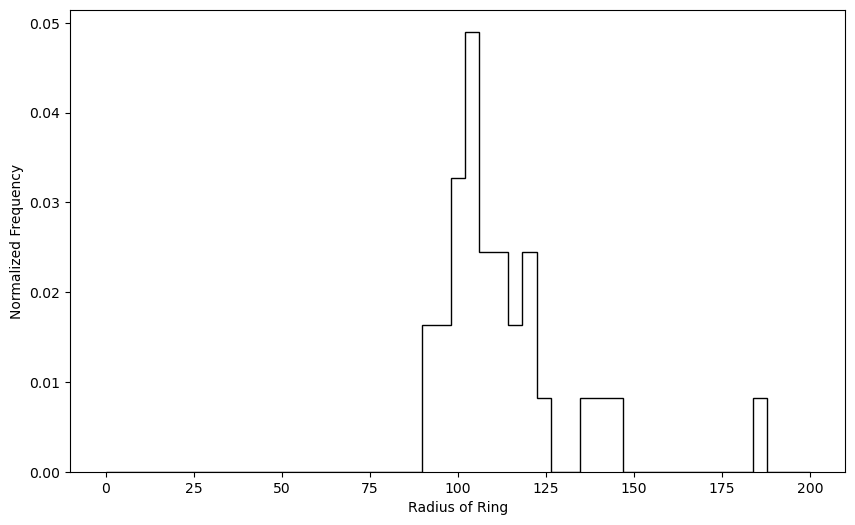

In [67]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[
        (muon_table['muonparameters_ring_intensity'] < 5000) &
        (muon_table['muonparameters_n_pixels_in_ring'] > 90)]['muonparameters_n_pixels_in_ring'],
    bins = np.linspace(0,200,50), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Radius of Ring')
plt.ylabel('Normalized Frequency')

Text(0, 0.5, 'Normalized Frequency')

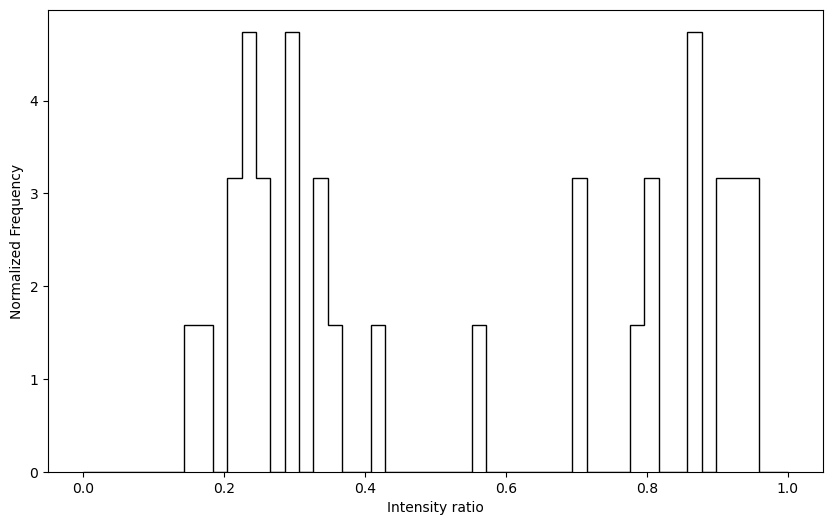

In [72]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[
        (muon_table['muonparameters_ring_intensity'] < 5000) &
        (muon_table['muonparameters_n_pixels_in_ring'] > 90)]['muonparameters_intensity_ratio'],
    bins = np.linspace(0,1,50), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Intensity ratio')
plt.ylabel('Normalized Frequency')

In [77]:
muon_table[(muon_table['muonparameters_ring_intensity'] < 5000) & 
                       (muon_table['muonparameters_n_pixels_in_ring'] > 90)]['event_id']

599365
599488
601012
601230
604850
612284
613427
617775
619929
620894
621230


In [108]:
muon_mask = (muon_table['muonparameters_ring_intensity'] < 500000000) & \
            (muon_table['muonparameters_n_pixels_in_ring'] > 60) & \
            (muon_table['muonparameters_intensity_ratio'] > 0.5)

# Get the event IDs from the filtered muon_table
filtered_event_ids = muon_table[muon_mask]['event_id']
# filtered_event_ids = muon_table[(muon_table['muonparameters_ring_intensity'] < 5000) & 
#                        (muon_table['muonparameters_n_pixels_in_ring'] > 99)]['event_id']
image_mask = np.isin(image_table['event_id'], filtered_event_ids)
image_table[image_mask]

obs_id,event_id,tel_id,image,peak_time,image_mask,is_valid
int64,int64,int16,float32[1855],float32[1855],bool[1855],bool
16903,599488,1,-1.2080032 .. 0.27462965,14.830133 .. 14.234669,False .. False,True
16903,601012,1,-0.022836098 .. -0.9223021,15.749668 .. 14.040293,False .. False,True
16903,601230,1,5.190361 .. -1.4494538,12.246879 .. 14.9450245,True .. False,True
16903,612284,1,-0.6138249 .. 2.029478,15.985768 .. 12.883168,False .. False,True
16903,617775,1,2.8451355 .. 0.5421237,9.818261 .. 12.779331,False .. False,True
16903,626589,1,0.19376788 .. 1.4212803,12.495061 .. 12.39039,False .. False,True
16903,627048,1,1.2131836 .. -1.0324141,12.543579 .. 14.96304,False .. False,True
16903,635540,1,-1.0698915 .. -1.1240269,7.4453135 .. 11.496837,False .. False,True
16903,637274,1,0.7183452 .. -0.21742098,14.542325 .. 11.609222,False .. False,True


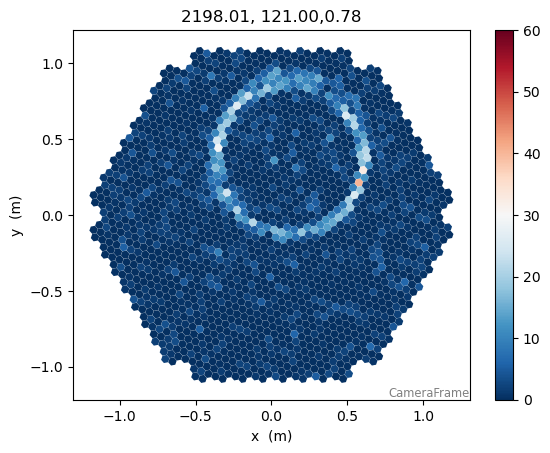

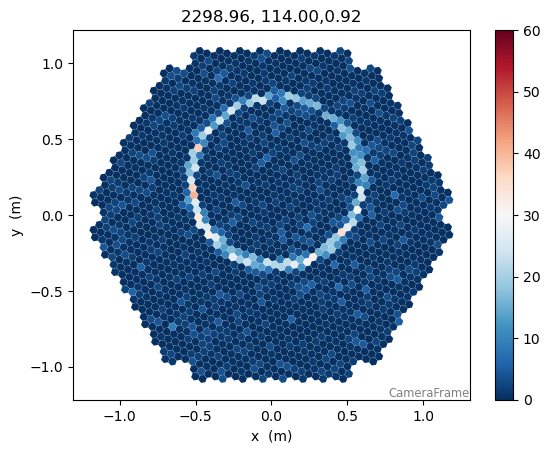

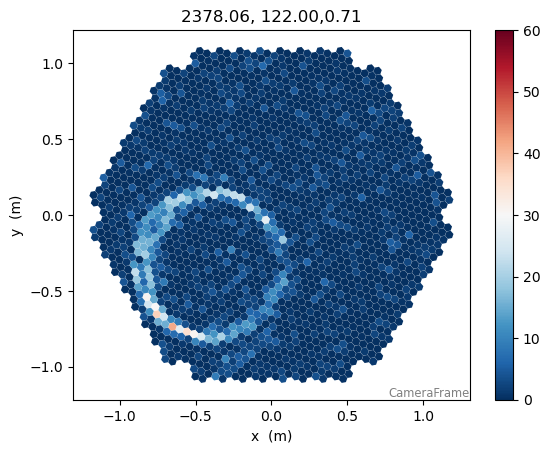

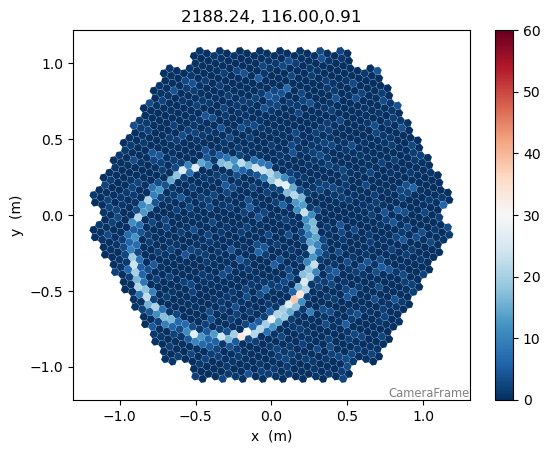

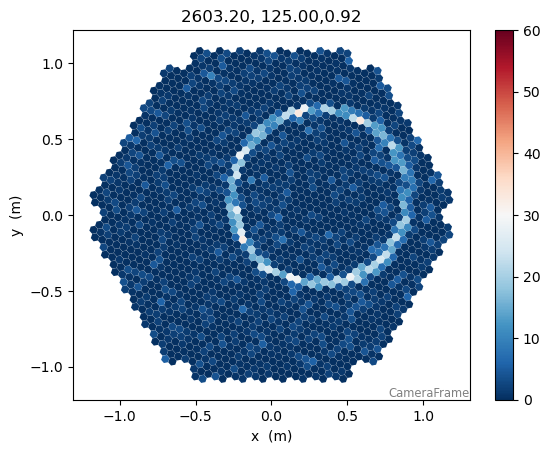

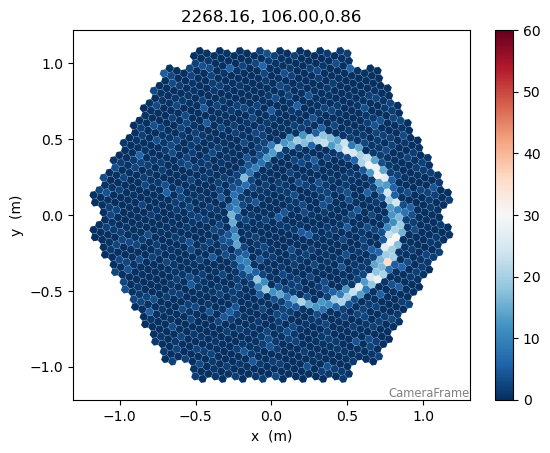

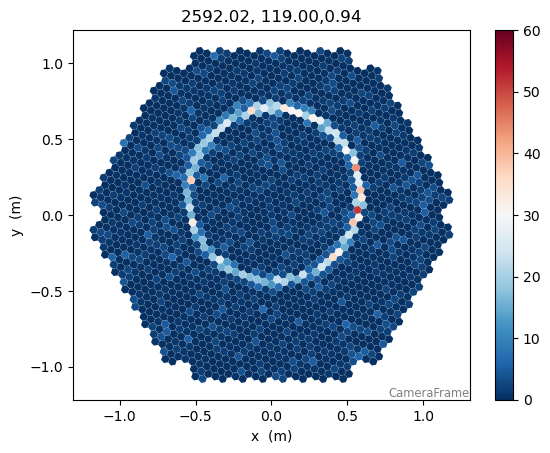

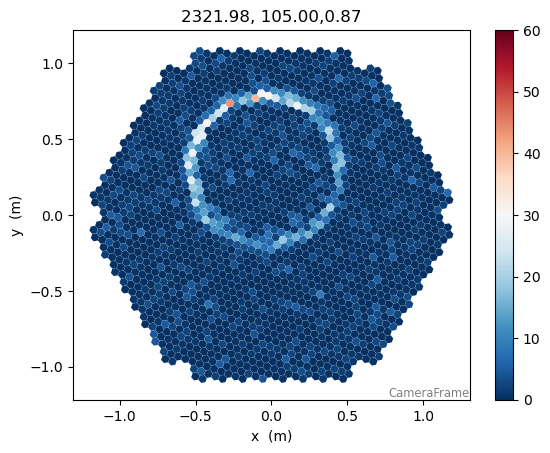

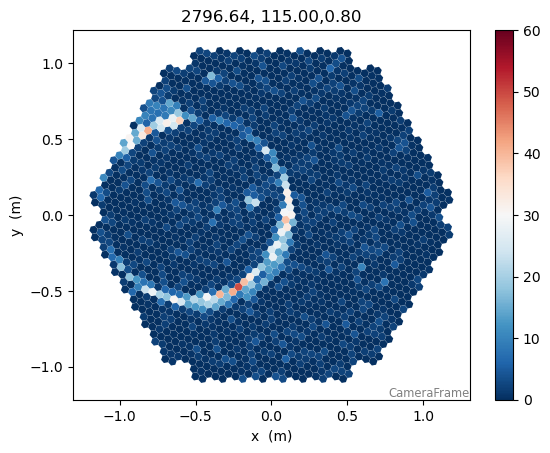

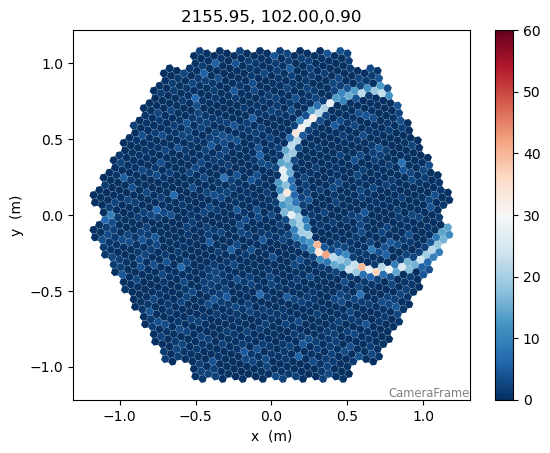

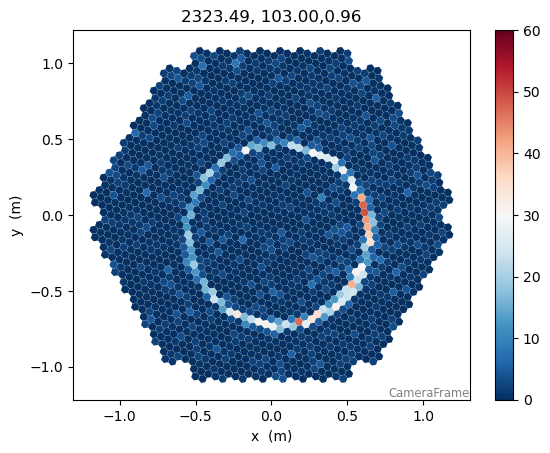

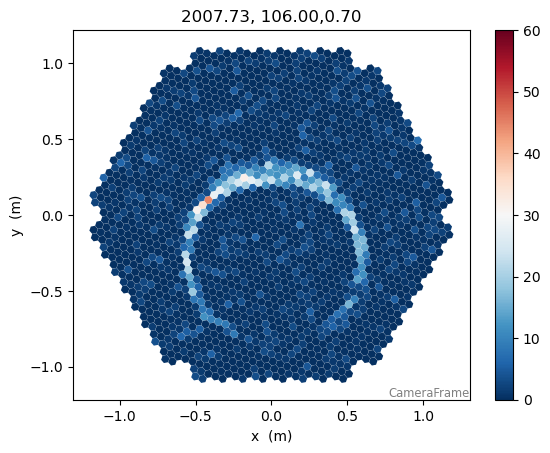

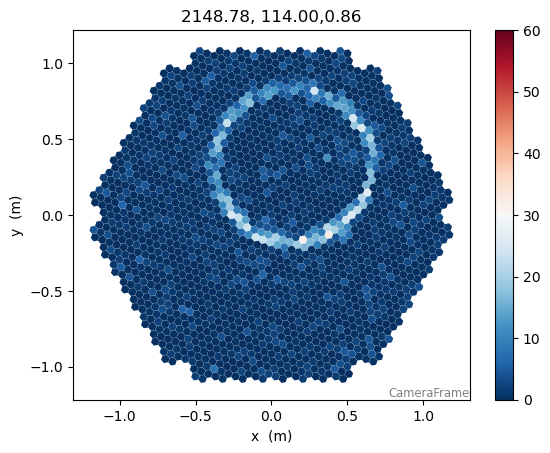

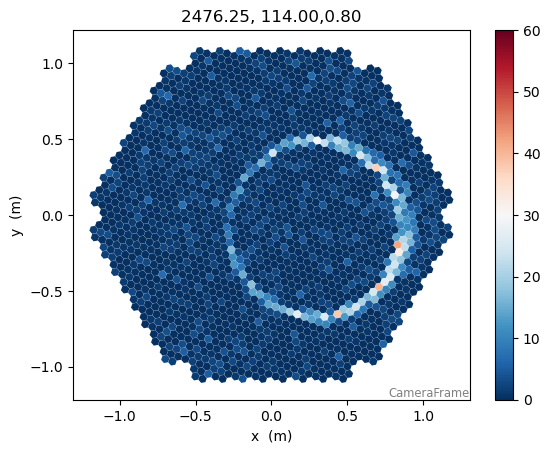

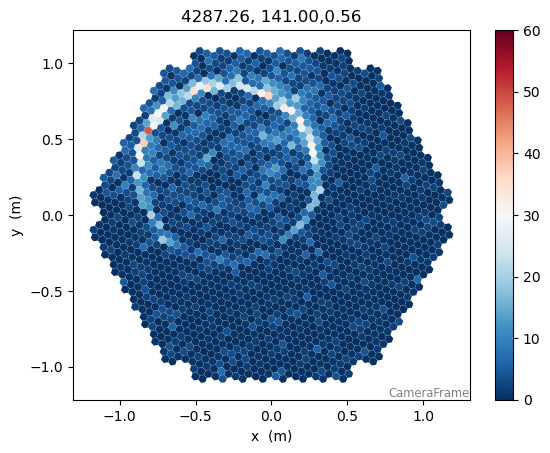

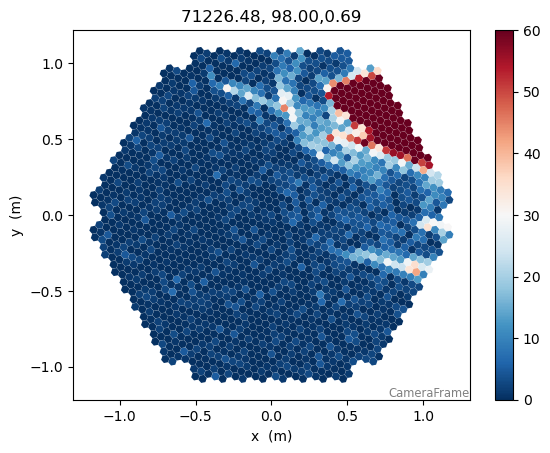

In [109]:
for event_id in range(0, len(image_table[image_mask])):
    disp = CameraDisplay(camgeom, image=image_table[image_mask]['image'][event_id])
    disp.cmap = plt.cm.RdBu_r
    disp.add_colorbar()
    #disp.set_limits_percent(95)
    disp.set_limits_minmax(0, 60)
    plt.title(f"{np.sum(image_table[image_mask]['image'][event_id]):.2f}, "
              f"{muon_table[muon_mask]['muonparameters_n_pixels_in_ring'][event_id]:.2f},"
              f"{muon_table[muon_mask]['muonparameters_intensity_ratio'][event_id]:.2f}")

    plt.show()

Text(0, 0.5, 'Normalized Frequency')

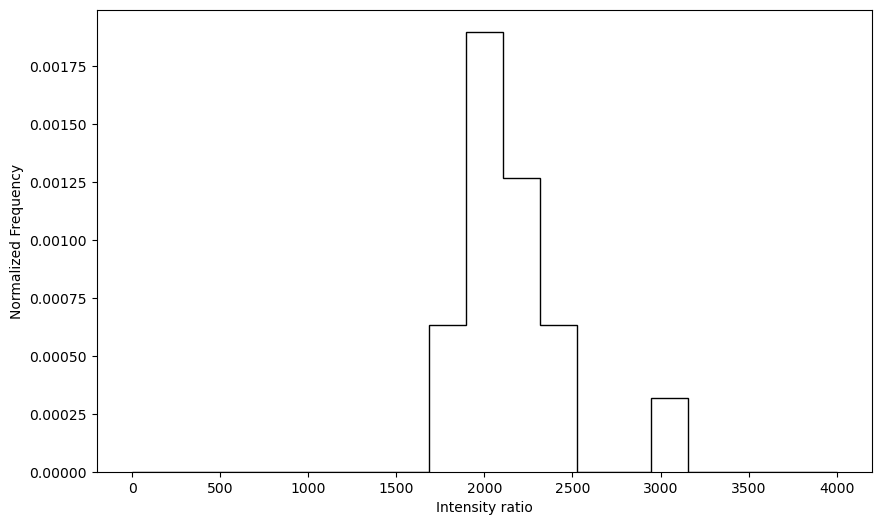

In [106]:
plt.figure(figsize=(10, 6))

z,x,c = plt.hist(
    muon_table[muon_mask]['muonparameters_ring_intensity'],
    bins = np.linspace(0,4000,20), 
    alpha=1, 
    color='k', 
    density=True, 
    label='Data', 
    histtype='step', 
    lw=2
)
plt.xlabel('Intensity ratio')
plt.ylabel('Normalized Frequency')